## SDM274 Assignment 09 - Dimensionality Reduction and Autoencoders

**Objective**:

In this assignment, you will explore dimensionality reduction using Principal Component Analysis (PCA) and simple Autoencoders (both linear and non-linear) on the Wine dataset. You will implement these algorithms in Python using NumPy and compare their reconstruction errors.

**Dataset**:

The Wine dataset can be found at the UCI Machine Learning Repository: [Wine Dataset](https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data). Please download the dataset and load it into your Python environment.

**Tasks**:

1. Implement PCA:
   - Write a Python function using NumPy to perform PCA on the Wine dataset.
   - Consider only the first two principal components for dimensionality reduction.
   - Reconstruct the data using these two principal components.
   - Visualize the principal compoenents in the two dimensional space.

2. Train a Linear Autoencoder:
   - Implement a linear autoencoder using a neural network design.
   - Train the autoencoder on the Wine dataset.
   - Reconstruct the data using the trained autoencoder.
   - Visual lize the output of the encoder; Calculate and report the reconstruction error.

3. Train a Non-linear Autoencoder:
   - Implement a non-linear autoencoder with at least one hidden layer that uses an activation function (e.g., ReLU).
   - Train the non-linear autoencoder on the Wine dataset.
   - Reconstruct the data using the trained autoencoder.
   - Visual lize the output of the encoder; Calculate and report the reconstruction error.

4. Comparison and Analysis:
   - Compare the reconstruction errors of the PCA, linear autoencoder, and non-linear autoencoder.
   - Analyze the results and discuss which method provides the best reconstruction accuracy and why.

**Submission**:

Submit your Python code, visualizations, and a written analysis of the results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

### Dataset

In [2]:
wine_csv = pd.read_csv('wine.data', header = None)
wine_csv.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = wine_csv.iloc[:, 1:].values, wine_csv.iloc[:, 0].values

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

### PCA

In [4]:
# covariance matrix
C = np.cov(X_scaled.T)
eigenvalues, eigenvectors = np.linalg.eig(C)

# sort eigenpairs by eigenvalues
eigenpairs = [(np.abs(eigenvalues[i]), eigenvectors[:, i]) for i in range(len(eigenvalues))]
eigenpairs.sort(key = lambda k: k[0], reverse = True) # sort by eigenvalue in descending order

# pick the top 2 eigenvectors
U_pca = np.hstack((eigenpairs[0][1][:, np.newaxis], eigenpairs[1][1][:, np.newaxis]))
print('U_pca:\n', U_pca)

U_pca:
 [[-0.1443294   0.48365155]
 [ 0.24518758  0.22493093]
 [ 0.00205106  0.31606881]
 [ 0.23932041 -0.0105905 ]
 [-0.14199204  0.299634  ]
 [-0.39466085  0.06503951]
 [-0.4229343  -0.00335981]
 [ 0.2985331   0.02877949]
 [-0.31342949  0.03930172]
 [ 0.0886167   0.52999567]
 [-0.29671456 -0.27923515]
 [-0.37616741 -0.16449619]
 [-0.28675223  0.36490283]]


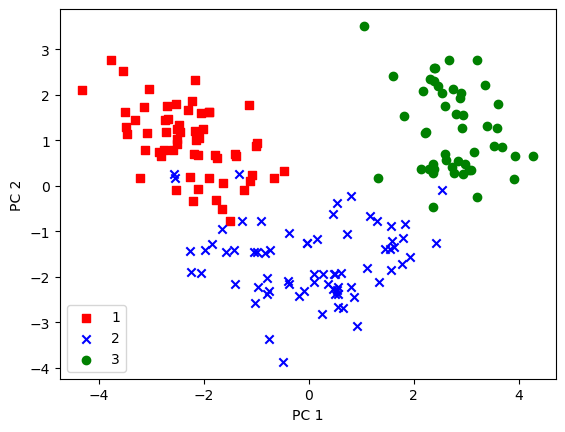

In [5]:
# project the training data onto the two principal components
X_pca = X_scaled.dot(U_pca)

# plot the training data on the two principal components
colors = ['r', 'b', 'g']
markers = ['s', 'x', 'o']
for l, c, m in zip(np.unique(y), colors, markers):
    plt.scatter(X_pca[y == l, 0], X_pca[y == l, 1], c = c, label = l, marker = m)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc = 'lower left')
plt.show()

In [6]:
from sklearn.metrics import mean_squared_error

# reconstruct the data
X_reconstructed = X_pca.dot(U_pca.T)

# calculate the reconstruction error
reconstruction_error = mean_squared_error(X_scaled, X_reconstructed)
print('Reconstruction error:', reconstruction_error)

Reconstruction error: 0.4459366164306473


### Linear Autoencoder

Import the `simple_ml` module for neural network implementation and wrap the dataset.

In [7]:
from simple_ml.model import *
from simple_ml.model.layers import *
from simple_ml.data.dataset import *
from simple_ml.data.samples import *
from simple_ml.training.loss import *
from simple_ml.training.optimizer import *
from simple_ml.evaluation.criterion import *

dataset = Dataset(data = X_scaled)

Build and train the linear autoencoder model.

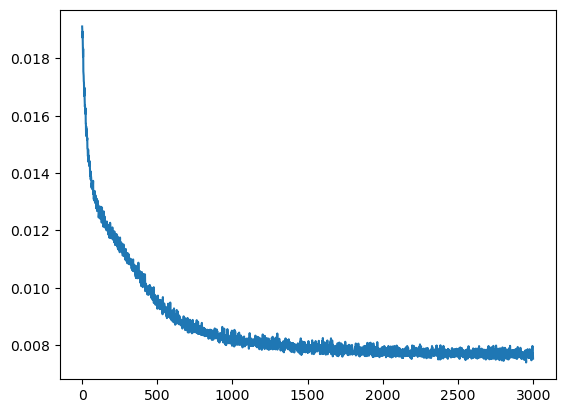

In [8]:
model = Sequential([
    Linear(X_scaled.shape[1], 2),
    Linear(2, X_scaled.shape[1])
])
loss_func = MSELoss()
optimizer = GD(model.parameters(), lr = 0.003)

iter = DataIterator(dataset, batch_size = 32, shuffle = True, cyclic = False)

epoch_num = 3000

loss_buffer = []

for epoch in range(epoch_num):
    loss = 0

    for batch, features in enumerate(iter): # features is both input and output
        prediction = model(Variable(features))
        loss += loss_func(prediction, features)

        model.backward()
        optimizer.step()
    
    loss /= len(dataset)
    loss_buffer.append(loss)

    # if (epoch + 1) % (epoch_num // 10) == 0:
    #     print(f'Epoch: {epoch + 1} / {epoch_num}')

fig = plt.figure(1)
plt.plot(np.arange(len(loss_buffer)), loss_buffer)
plt.show()

Visualize the encoder output on the two-dimensional space.

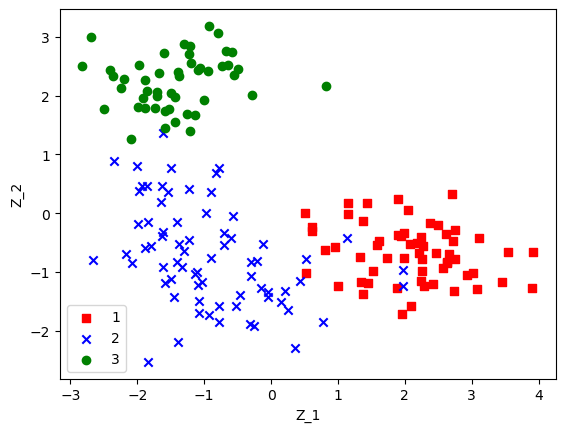

In [9]:
# encode the training data
X_encoded = model.layers[0].forward(Variable(dataset.datas)).value

# plot the training data on the two principal components
colors = ['r', 'b', 'g']
markers = ['s', 'x', 'o']
for l, c, m in zip(np.unique(y), colors, markers):
    plt.scatter(X_encoded[y == l, 0], X_encoded[y == l, 1], c = c, label = l, marker = m)
plt.xlabel('Z_1')
plt.ylabel('Z_2')
plt.legend(loc = 'lower left')
plt.show()

Calculate the reconstruction error.

In [10]:
# calculate the reconstruction error
X_reconstructed = model(Variable(dataset.datas)).value
reconstruction_error = mean_squared_error(X_scaled, X_reconstructed)
print('Reconstruction error:', reconstruction_error)

Reconstruction error: 0.4540325401333383


### Non-linear Autoencoder

Similarly, build and train the non-linear autoencoder model by adding a non-linear activation function.

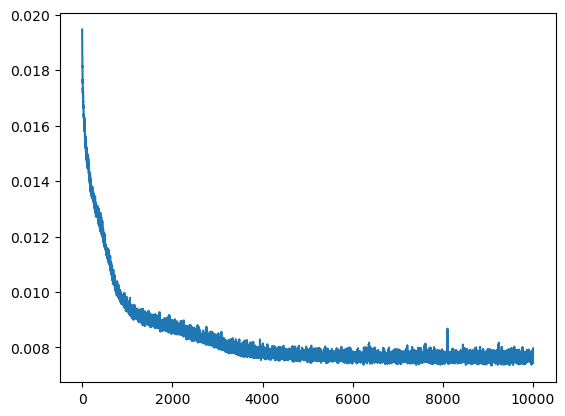

In [21]:
model = Sequential([
    Linear(X_scaled.shape[1], 2),
    ReLU(),
    Linear(2, X_scaled.shape[1])
])
loss_func = MSELoss()
optimizer = Adam(model.parameters(), lr = 0.001)

iter = DataIterator(dataset, batch_size = 32, shuffle = True, cyclic = False)

epoch_num = 10000

loss_buffer = []

for epoch in range(epoch_num):
    loss = 0

    for batch, features in enumerate(iter): # features is both input and output
        prediction = model(Variable(features))
        loss += loss_func(prediction, features)

        model.backward()
        optimizer.step()
    
    loss /= len(dataset)
    loss_buffer.append(loss)

    # if (epoch + 1) % (epoch_num // 10) == 0:
    #     print(f'Epoch: {epoch + 1} / {epoch_num}')

fig = plt.figure(1)
plt.plot(np.arange(len(loss_buffer)), loss_buffer)
plt.show()

Plot the encoder output on the two-dimensional space.

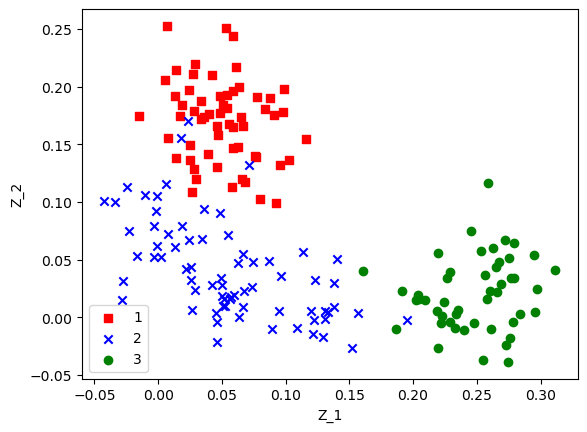

In [22]:
# encode the training data
X_encoded = model.layers[0].forward(Variable(dataset.datas)).value

# plot the training data on the two principal components
colors = ['r', 'b', 'g']
markers = ['s', 'x', 'o']
for l, c, m in zip(np.unique(y), colors, markers):
    plt.scatter(X_encoded[y == l, 0], X_encoded[y == l, 1], c = c, label = l, marker = m)
plt.xlabel('Z_1')
plt.ylabel('Z_2')
plt.legend(loc = 'lower left')
plt.show()

Calculate the reconstruction error.

In [23]:
# calculate the reconstruction error
X_reconstructed = model(Variable(dataset.datas)).value
reconstruction_error = mean_squared_error(X_scaled, X_reconstructed)
print('Reconstruction error:', reconstruction_error)

Reconstruction error: 0.46651077827263976


### Comparison and Analysis

As shown earlier, the Reconstruction Error for each of the three methods in a single run is:

| Method | Reconstruction Error |
| --- | --- |
| PCA (2 principle components) | 0.4459366164306473 |
| Linear Autoencoder (1 hidden layer with 2 neurons) | 0.4540325401333383 |
| Non-linear Autoencoder (1 hidden layer with 2 neurons, ReLU) | 0.46651077827263976 |

It can be observed that PCA has the lowest Reconstruction Error, Linear Autoencoder the second highest and Non-linear Autoencoder the highest.

The Reconstruction Error of the first two is similar because theoretically Linear Autoencoder is equivalent to PCA, but it may be due to the randomness in the training process, which leads to a slight difference in the Reconstruction Error of the two. Observation of the visualisation image also shows that the two are basically rotated and flipped.

The Non-linear Autoencoder has the highest Reconstruction Error, probably due to the complexity of the model leading to overfitting, i.e. the dataset is relatively simple and the non-linear model instead learns the noise in as well. However, its results are not much worse than the first two, still due to the relative simplicity of the model, which retains only two features after encoding.